# 01 · EDA — Captions & Justifications

Exploratory analysis of the textual outputs (captions and justifications) produced by persona-driven MLLM annotators.

**Goals**
- Understand text length distributions per condition, persona, and sentiment label
- Vocabulary richness and lexical diversity
- Label (perception tag) frequency and co-occurrence
- Baseline statistics to motivate subsequent analyses

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter

DATA_PATH = Path("../data/annotations_baseline.jsonl")
FIGURES   = Path("../figures")
OUTPUTS   = Path("../outputs")
FIGURES.mkdir(exist_ok=True)
OUTPUTS.mkdir(exist_ok=True)

FONT_SCALE = 1.4
sns.set_theme(style="whitegrid", font_scale=FONT_SCALE)
plt.rcParams["figure.dpi"] = 150

MUTED = sns.color_palette("muted")  # [#4878d0, #ee854a, #6acc64, #d65f5f, ...]
SENT_COLORS = {
    "Negative":         "#d73027",
    "SlightlyNegative": "#fc8d59",
    "Neutral":          "#aaaaaa",
    "SlightlyPositive": "#91cf60",
    "Positive":         "#1a9850",
}
SENT_COLORS_3 = {k: SENT_COLORS[k] for k in ["Negative", "Neutral", "Positive"]}


In [2]:
records = []
with DATA_PATH.open() as fh:
    for line in fh:
        records.append(json.loads(line))

df = pd.DataFrame(records)
df["caption_len"]       = df["caption"].str.split().str.len()
df["justification_len"] = df["justification"].str.split().str.len()
df["n_perceptions"]     = df["predicted_perceptions"].apply(len)

print(f"Records : {len(df):,}")
print(f"Images  : {df['image_id'].nunique():,}")
print(f"Personas: {df['persona_id'].nunique():,}")
df.head(2)

Records : 59,708
Images  : 50
Personas: 1,200


,annotation_id,persona_id,image_id,condition,raw_demographics,predicted_sentiment,predicted_perceptions,caption,justification,parse_retries,timestamp_utc,caption_len,justification_len,n_perceptions
0,p04f4ad2a_img_1eV8XkQbq8rECy6hbZrN1_qwSRyWXDqs...,04f4ad2a-d1df-4de3-b33a-e48b8bcc1102,1eV8XkQbq8rECy6hbZrN1_qwSRyWXDqsK,baseline,"{'gender': 'Female', 'economic_status': 'Low i...",Negative,"[Abandoned, Lack of Maintenance]",A weathered building facade with a rusted meta...,This looks like a neglected building that's be...,0,2026-02-27T04:51:25Z,16,21,2
1,p04f4ad2a_img_1Q_gMcjg8yrq2M7OCj1uBySMtP03fZgx...,04f4ad2a-d1df-4de3-b33a-e48b8bcc1102,1Q_gMcjg8yrq2M7OCj1uBySMtP03fZgx-,baseline,"{'gender': 'Female', 'economic_status': 'Low i...",SlightlyPositive,"[Urban environment, Cleanliness, Everyday envi...","A tall brick building with a stone base, surro...","A clean, well-maintained city scene with order...",0,2026-02-27T04:52:04Z,25,19,5


## 0 · Justification structure: terms or sentences?

Before running topic modeling on justifications it is important to confirm they are full prose sentences, not keyword lists. The median length (18 words) already suggests this; the examples below confirm it.

In [ ]:
import textwrap

print(f"Median justification length : {df['justification_len'].median():.0f} words")
print(f"Median caption length       : {df['caption_len'].median():.0f} words")
print()

print("─" * 80)
print("Sample justifications (one per predicted-sentiment class)")
print("─" * 80)
for label in ["Negative", "SlightlyNegative", "Neutral", "SlightlyPositive", "Positive"]:
    sample = df[df["predicted_sentiment"] == label]["justification"].dropna().iloc[0]
    print(f"[{label:18s}] {textwrap.fill(sample, width=70, subsequent_indent=' ' * 22)}")
print()
print("→ Justifications are full sentences written in the persona's voice,")
print("  making sentence-embedding and topic modeling appropriate.")


## 1 · Sentiment label distribution

/tmp/ipykernel_77089/649333592.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="predicted_sentiment", order=order, palette=bar_colors, ax=ax)


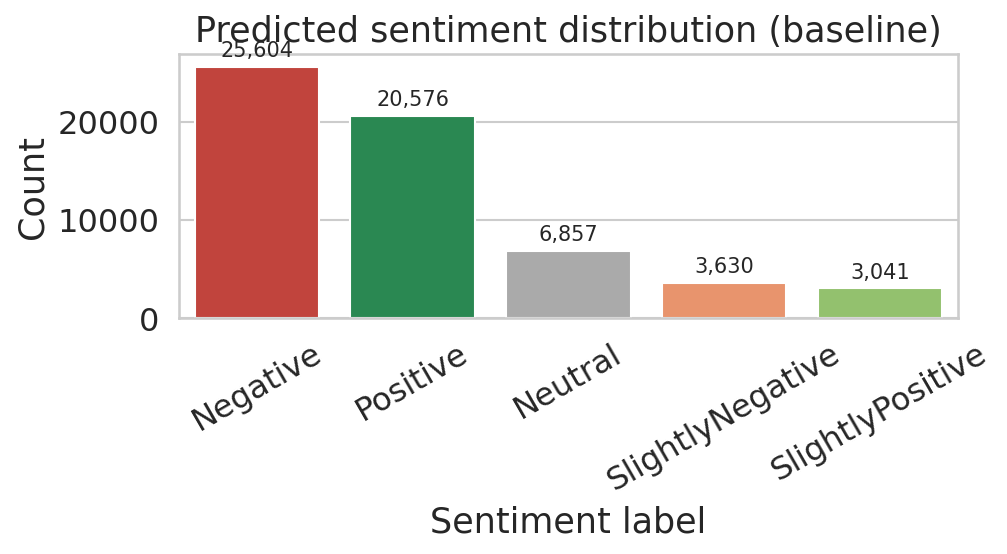

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
order = df["predicted_sentiment"].value_counts().index.tolist()
bar_colors = [SENT_COLORS.get(l, MUTED[0]) for l in order]
sns.countplot(data=df, x="predicted_sentiment", order=order, palette=bar_colors, ax=ax)
ax.set_xlabel("Sentiment label")
ax.set_ylabel("Count")
ax.set_title("Predicted sentiment distribution (baseline)")
ax.tick_params(axis="x", rotation=30)
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=10,
        xytext=(0, 3), textcoords="offset points",
    )
plt.tight_layout()
fig.savefig(FIGURES / "fig_eda_sentiment_dist.pdf")
fig.savefig(FIGURES / "fig_eda_sentiment_dist.png")
plt.show()


## 2 · Text length distributions (caption vs. justification)

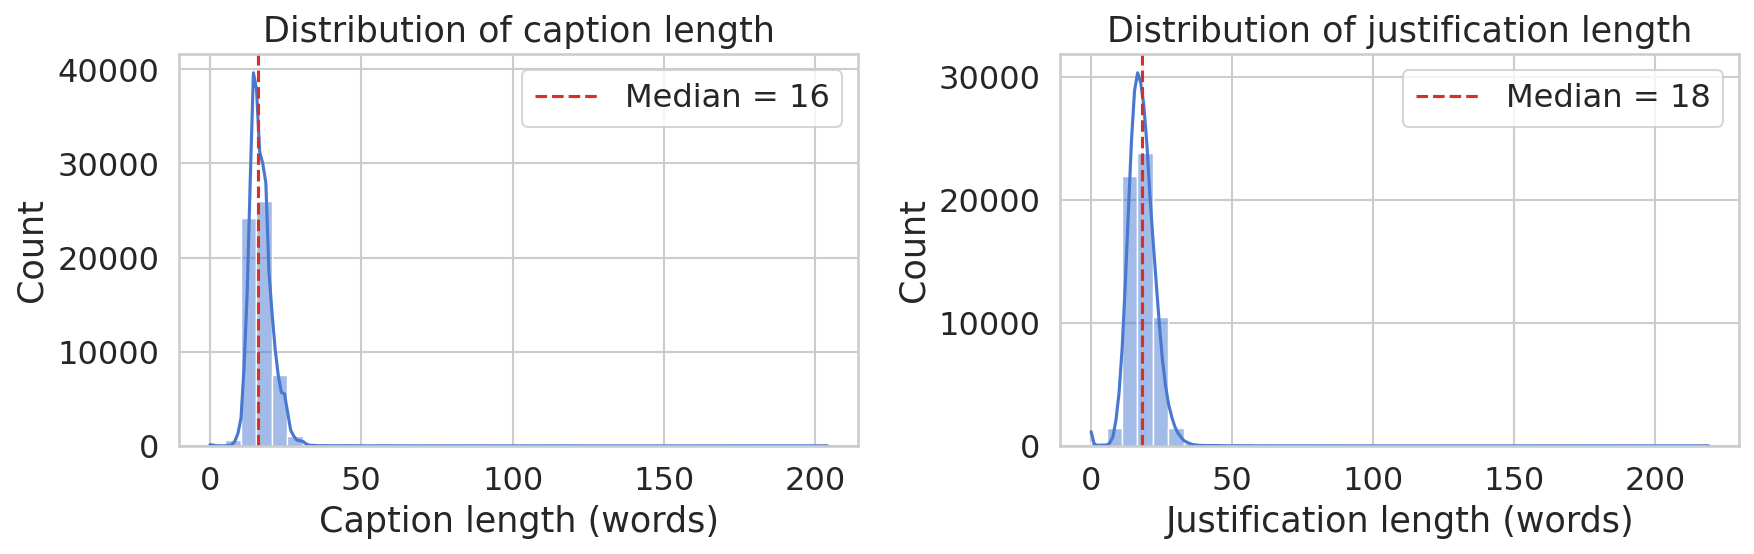

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(axes,
                           ["caption_len", "justification_len"],
                           ["Caption length (words)", "Justification length (words)"]):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color=MUTED[0])
    ax.set_xlabel(title)
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {title.split()[0].lower()} length")
    ax.axvline(df[col].median(), color="#d73027", linestyle="--",
               label=f"Median = {df[col].median():.0f}")
    ax.legend()

plt.tight_layout()
fig.savefig(FIGURES / "fig_eda_text_length_dist.pdf")
fig.savefig(FIGURES / "fig_eda_text_length_dist.png")
plt.show()


## 3 · Length by sentiment label

/tmp/ipykernel_77089/211185838.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df["predicted_sentiment"].isin(sentiment_order)],
/tmp/ipykernel_77089/211185838.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df["predicted_sentiment"].isin(sentiment_order)],


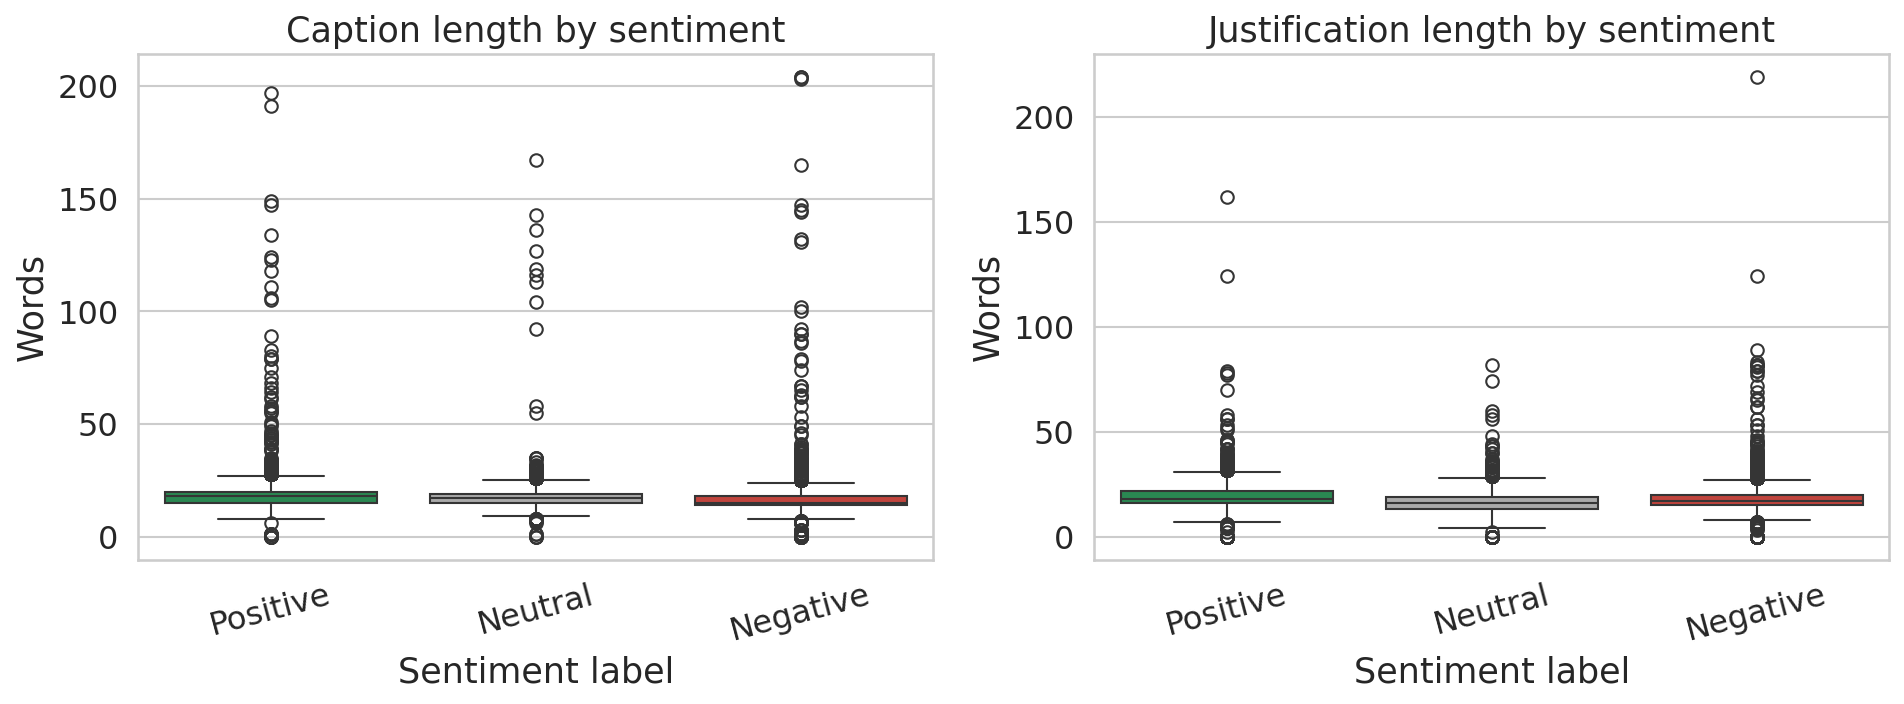

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sentiment_order = ["Positive", "Neutral", "Negative"]

for ax, col, title in zip(axes,
                           ["caption_len", "justification_len"],
                           ["Caption length", "Justification length"]):
    bp_palette = [SENT_COLORS_3[s] for s in sentiment_order]
    sns.boxplot(data=df[df["predicted_sentiment"].isin(sentiment_order)],
                x="predicted_sentiment", y=col, order=sentiment_order,
                palette=bp_palette, ax=ax)
    ax.set_xlabel("Sentiment label")
    ax.set_ylabel("Words")
    ax.set_title(f"{title} by sentiment")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
fig.savefig(FIGURES / "fig_eda_length_by_sentiment.pdf")
fig.savefig(FIGURES / "fig_eda_length_by_sentiment.png")
plt.show()


## 4 · Top perception tags

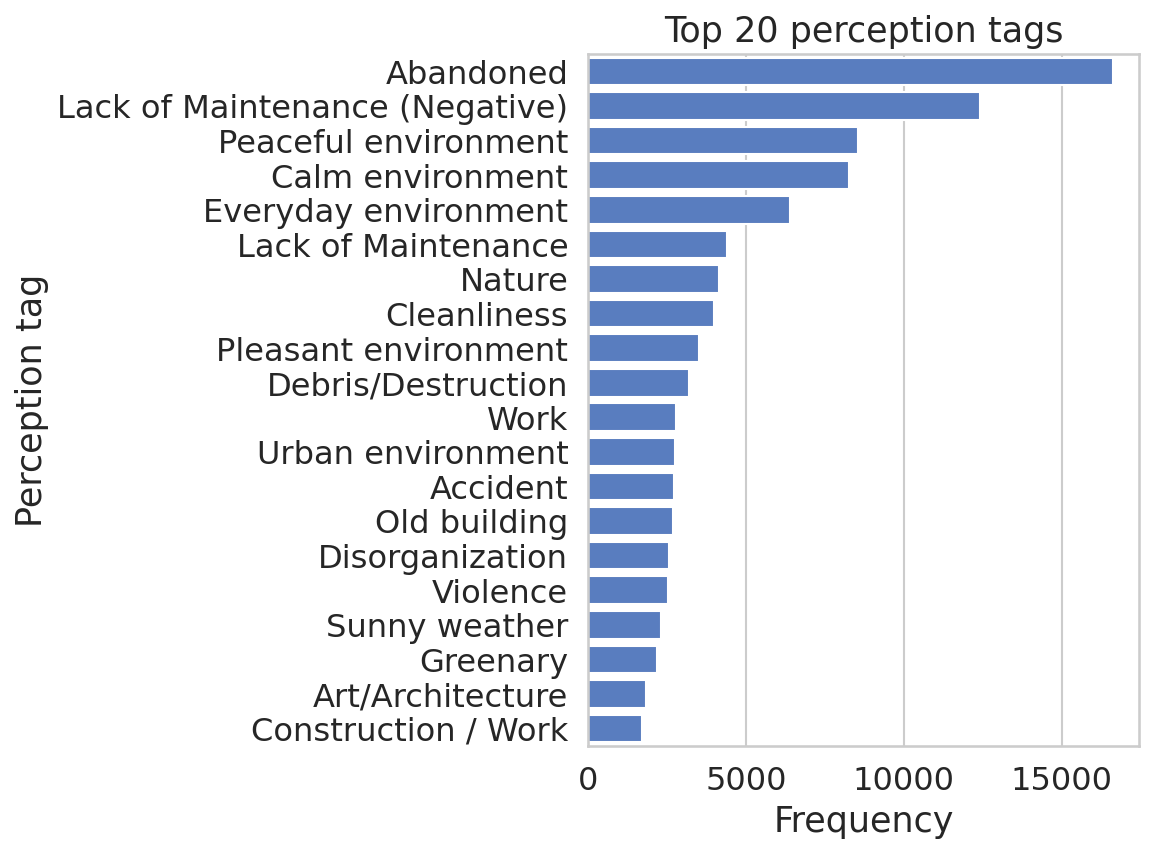

                           tag  count
                     Abandoned  16626
Lack of Maintenance (Negative)  12398
          Peaceful environment   8538
              Calm environment   8248
          Everyday environment   6385
           Lack of Maintenance   4395
                        Nature   4133
                   Cleanliness   3985
          Pleasant environment   3519
            Debris/Destruction   3182
                          Work   2770
             Urban environment   2736
                      Accident   2705
                  Old building   2674
               Disorganization   2571
                      Violence   2543
                 Sunny weather   2308
                      Greenary   2175
              Art/Architecture   1848
           Construction / Work   1708


In [6]:
all_tags = [tag for tags in df["predicted_perceptions"] for tag in tags]
tag_counts = Counter(all_tags)
top_n = 20
top_tags = pd.DataFrame(tag_counts.most_common(top_n), columns=["tag", "count"])

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=top_tags, y="tag", x="count", color=MUTED[0], ax=ax)
ax.set_xlabel("Frequency")
ax.set_ylabel("Perception tag")
ax.set_title(f"Top {top_n} perception tags")
plt.tight_layout()
fig.savefig(FIGURES / "fig_eda_top_perception_tags.pdf")
fig.savefig(FIGURES / "fig_eda_top_perception_tags.png")
plt.show()

top_tags.to_csv(OUTPUTS / "top_perception_tags.csv", index=False)
print(top_tags.to_string(index=False))


## 5 · Perception tag co-occurrence heatmap (top 15)

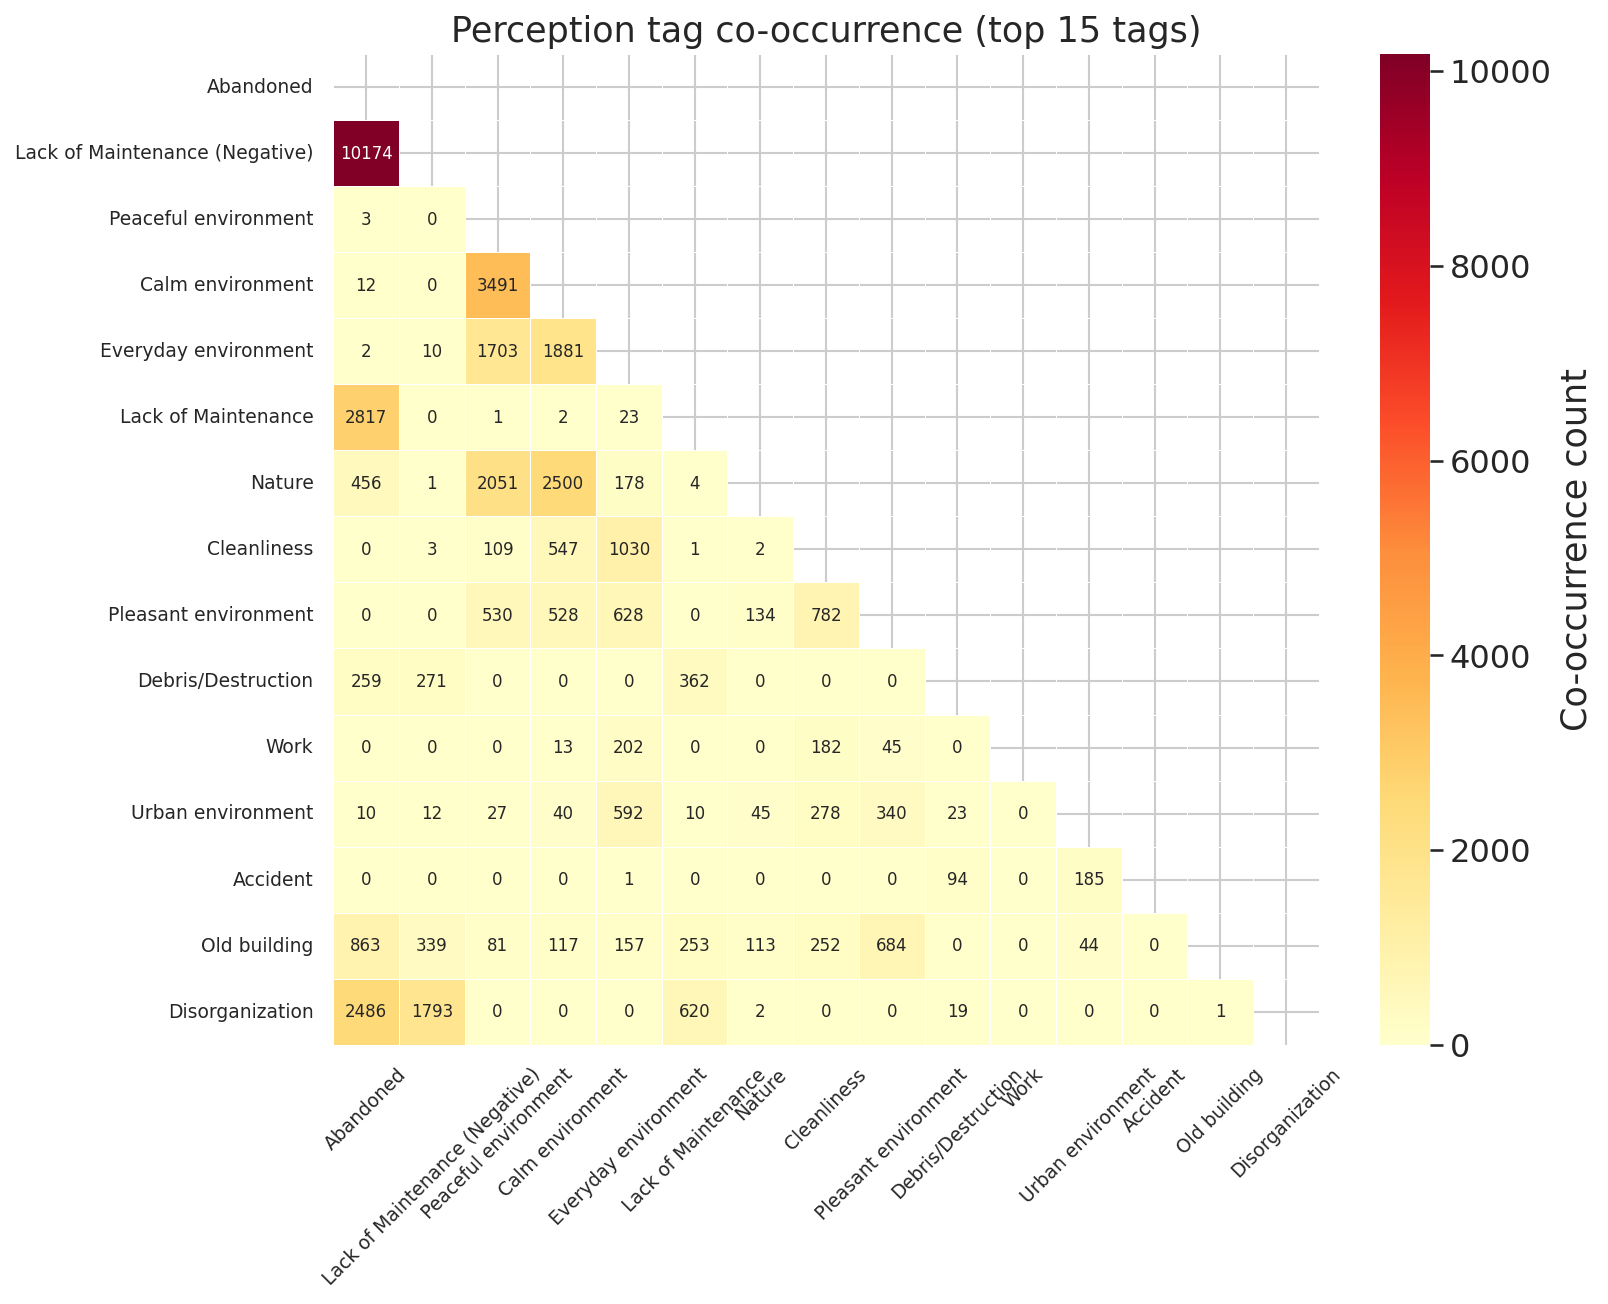

In [7]:
top15 = [t for t, _ in tag_counts.most_common(15)]
co_matrix = pd.DataFrame(0, index=top15, columns=top15)

for tags in df["predicted_perceptions"]:
    present = [t for t in tags if t in top15]
    for i, a in enumerate(present):
        for b in present[i:]:
            co_matrix.loc[a, b] += 1
            if a != b:
                co_matrix.loc[b, a] += 1

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(co_matrix, dtype=bool))
sns.heatmap(
    co_matrix, mask=mask, cmap="YlOrRd", annot=True, fmt="d",
    linewidths=0.4, ax=ax, cbar_kws={"label": "Co-occurrence count"},
    annot_kws={"size": 8},
)
ax.set_title("Perception tag co-occurrence (top 15 tags)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)
plt.tight_layout()
fig.savefig(FIGURES / "fig_eda_tag_cooccurrence.pdf")
fig.savefig(FIGURES / "fig_eda_tag_cooccurrence.png")
plt.show()


## 6 · Save EDA summary stats

In [8]:
summary = df[["caption_len", "justification_len", "n_perceptions"]].describe().round(2)
print(summary)
summary.to_csv(OUTPUTS / "eda_summary_stats.csv")

       caption_len  justification_len  n_perceptions
count     59708.00           59708.00       59708.00
mean         16.93              18.01           2.59
std           4.98               4.94           0.67
min           0.00               0.00           0.00
25%          14.00              15.00           2.00
50%          16.00              18.00           3.00
75%          19.00              21.00           3.00
max         204.00             219.00           6.00
